In [2]:
import cv2
import numpy as np

# Load the image from disk
img = cv2.imread(r"C:\Users\DIN REAKSA\Desktop\Blurring\01.png")

# Inspect what we actually got
print("Type:", type(img))
print("Shape (height, width, channels):", img.shape)
print("Data type:", img.dtype)
print("First pixel (top-left corner):", img[0, 0])

Type: <class 'numpy.ndarray'>
Shape (height, width, channels): (516, 387, 3)
Data type: uint8
First pixel (top-left corner): [227 229 229]


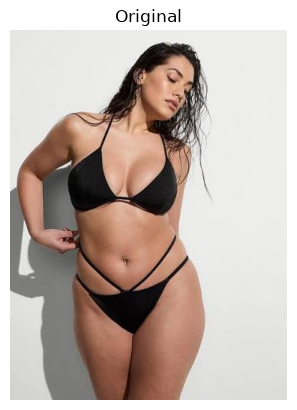

In [14]:
import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.title("Original")
plt.show()

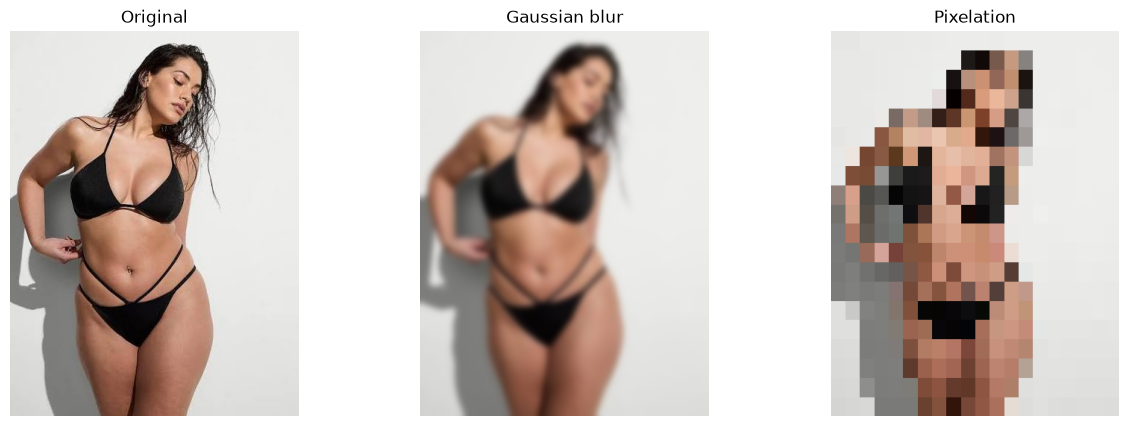

In [16]:
# Method 1: Gaussian blur
gaussian_result = cv2.GaussianBlur(img, (25, 25), 0)

# Method 2: Pixelation
def pixelate(image, block_count=20):
    h, w = image.shape[:2]
    small = cv2.resize(image, (block_count, block_count), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

pixelate_result = pixelate(img, block_count=20)

# Display all three side by side
gaussian_rgb = cv2.cvtColor(gaussian_result, cv2.COLOR_BGR2RGB)
pixelate_rgb = cv2.cvtColor(pixelate_result, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(gaussian_rgb); axes[1].set_title("Gaussian blur"); axes[1].axis("off")
axes[2].imshow(pixelate_rgb); axes[2].set_title("Pixelation"); axes[2].axis("off")
plt.show()

In [17]:
import psycopg2

conn = psycopg2.connect(
    dbname="demo_db",
    user="postgres",
    password="lusa123",
    host="localhost",
    port="5432"
)
cur = conn.cursor()

# Table 1: one row per original image
cur.execute("""
    CREATE TABLE IF NOT EXISTS originals (
        image_id     UUID PRIMARY KEY,
        original_img BYTEA NOT NULL,
        created_at   TIMESTAMP DEFAULT NOW()
    );
""")

# Table 2: one row per blurred variant, linked back to its original
cur.execute("""
    CREATE TABLE IF NOT EXISTS blurred_variants (
        variant_id    UUID PRIMARY KEY,
        image_id      UUID REFERENCES originals(image_id),
        blurred_img   BYTEA NOT NULL,
        blurred_hash  TEXT UNIQUE NOT NULL,
        blur_method   TEXT NOT NULL,
        created_at    TIMESTAMP DEFAULT NOW()
    );
""")

conn.commit()
print("Tables created (or already existed).")

Tables created (or already existed).


In [18]:
import uuid
import hashlib

success, encoded_x = cv2.imencode(".jpg", img)
x_bytes = encoded_x.tobytes()

image_id = str(uuid.uuid4())

cur.execute(
    "INSERT INTO originals (image_id, original_img) VALUES (%s, %s)",
    (image_id, psycopg2.Binary(x_bytes))
)
conn.commit()

print("Original stored. image_id:", image_id)



Original stored. image_id: 00da147c-0a85-49fa-9f4c-4d49302a91b2


In [19]:
def store_variant(image_id, blurred_array, method_name, cur, conn):
    success, encoded = cv2.imencode(".jpg", blurred_array)
    y_bytes = encoded.tobytes()
    y_hash = hashlib.sha256(y_bytes).hexdigest()
    variant_id = str(uuid.uuid4())

    cur.execute(
        """
        INSERT INTO blurred_variants (variant_id, image_id, blurred_img, blurred_hash, blur_method)
        VALUES (%s, %s, %s, %s, %s)
        """,
        (variant_id, image_id, psycopg2.Binary(y_bytes), y_hash, method_name)
    )
    conn.commit()
    print(f"Stored {method_name} variant. hash: {y_hash}")
    return y_hash

gaussian_hash = store_variant(image_id, gaussian_result, "gaussian", cur, conn)
pixelate_hash = store_variant(image_id, pixelate_result, "pixelate", cur, conn)



Stored gaussian variant. hash: aebd0d887e0b6a4e2c72b9eb3c1855d50216ee84a27d3068a93ecf91ccdd67aa
Stored pixelate variant. hash: 94894e444855a79ac44b4dee2b9208bd68b825b60acd8db5cdfb0c5604b6178f


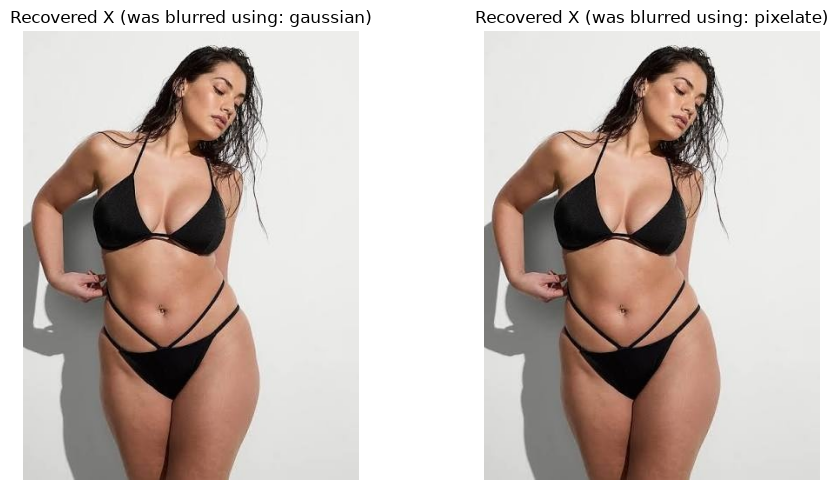

[(array([[[229, 229, 227],
          [229, 229, 227],
          [229, 229, 227],
          ...,
          [237, 237, 235],
          [237, 237, 235],
          [237, 237, 235]],
  
         [[229, 229, 227],
          [229, 229, 227],
          [229, 229, 227],
          ...,
          [237, 237, 235],
          [237, 237, 235],
          [237, 237, 235]],
  
         [[229, 229, 227],
          [229, 229, 227],
          [229, 229, 227],
          ...,
          [237, 237, 235],
          [237, 237, 235],
          [237, 237, 235]],
  
         ...,
  
         [[210, 210, 208],
          [210, 210, 208],
          [210, 210, 208],
          ...,
          [219, 219, 217],
          [219, 219, 217],
          [219, 219, 217]],
  
         [[210, 210, 208],
          [210, 210, 208],
          [210, 210, 208],
          ...,
          [219, 219, 217],
          [219, 219, 217],
          [219, 219, 217]],
  
         [[210, 210, 208],
          [210, 210, 208],
          [210, 210, 208

In [21]:
def reveal_originals(hashes, cur):
    """
    hashes: list of search hashes to look up
    Displays all recovered originals side-by-side using subplots.
    """
    results = []

    for search_hash in hashes:
        cur.execute(
            """
            SELECT o.original_img, v.blur_method
            FROM originals o
            JOIN blurred_variants v ON v.image_id = o.image_id
            WHERE v.blurred_hash = %s
            """,
            (search_hash,)
        )
        row = cur.fetchone()
        if row is None:
            print(f"No match found for hash: {search_hash}")
            results.append(None)
            continue

        original_bytes, method_used = row
        arr = np.frombuffer(bytes(original_bytes), dtype=np.uint8)
        recovered = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        recovered_rgb = cv2.cvtColor(recovered, cv2.COLOR_BGR2RGB)
        results.append((recovered_rgb, method_used))

    valid_results = [r for r in results if r is not None]
    if not valid_results:
        print("No images to display.")
        return results

    n = len(valid_results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]  # make iterable when there's only one subplot

    for ax, (recovered_rgb, method_used) in zip(axes, valid_results):
        ax.imshow(recovered_rgb)
        ax.axis("off")
        ax.set_title(f"Recovered X (was blurred using: {method_used})")

    plt.tight_layout()
    plt.show()

    return results

# Try it with both hashes — both lead back to the same X
reveal_originals([gaussian_hash, pixelate_hash], cur)

In [25]:
import psycopg2

def get_connection():
    return psycopg2.connect(
        dbname="demo_db",
        user="postgres",
        password="lusa123",
        host="localhost",
        port="5432"
    )

conn = get_connection()
print("Connected:", conn)
print("Closed?", conn.closed)
conn.close()
print("Closed after closing?", conn.closed)

Connected: <connection object at 0x0000029AF5B6FBC0; dsn: 'user=postgres password=xxx dbname=demo_db host=localhost port=5432', closed: 0>
Closed? 0
Closed after closing? 1


In [26]:
import uuid

def save_original(x_bytes):
    conn = get_connection()
    cur = conn.cursor()

    image_id = str(uuid.uuid4())

    cur.execute(
        "INSERT INTO originals (image_id, original_img) VALUES (%s, %s)",
        (image_id, psycopg2.Binary(x_bytes))
    )

    conn.commit()
    cur.close()
    conn.close()

    return image_id

In [27]:
success, encoded_x = cv2.imencode(".jpg", img)
x_bytes = encoded_x.tobytes()

new_image_id = save_original(x_bytes)
print("Saved original with image_id:", new_image_id)

Saved original with image_id: fc268cb2-ec6b-45fc-85a1-349ea0afc30c


In [30]:
import hashlib
import psycopg2

def save_variant(image_id, blurred_array, method_name):
    conn = get_connection()
    cur = conn.cursor()

    success, encoded = cv2.imencode(".jpg", blurred_array)
    y_bytes = encoded.tobytes()
    y_hash = hashlib.sha256(y_bytes).hexdigest()

    # Check if this exact blurred image was already stored
    cur.execute("SELECT variant_id FROM blurred_variants WHERE blurred_hash = %s", (y_hash,))
    existing = cur.fetchone()

    if existing:
        print(f"Variant already exists for this hash ({method_name}), reusing it.")
        cur.close()
        conn.close()
        return y_hash

    variant_id = str(uuid.uuid4())
    cur.execute(
        """
        INSERT INTO blurred_variants (variant_id, image_id, blurred_img, blurred_hash, blur_method)
        VALUES (%s, %s, %s, %s, %s)
        """,
        (variant_id, image_id, psycopg2.Binary(y_bytes), y_hash, method_name)
    )
    conn.commit()
    cur.close()
    conn.close()

    return y_hash

In [31]:
gaussian_result = cv2.GaussianBlur(img, (25, 25), 0)

def pixelate(image, block_count=20):
    h, w = image.shape[:2]
    small = cv2.resize(image, (block_count, block_count), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

pixelate_result = pixelate(img, block_count=20)

gaussian_hash = save_variant(new_image_id, gaussian_result, "gaussian")
pixelate_hash = save_variant(new_image_id, pixelate_result, "pixelate")

print("Gaussian hash:", gaussian_hash)
print("Pixelate hash:", pixelate_hash)

Variant already exists for this hash (gaussian), reusing it.
Variant already exists for this hash (pixelate), reusing it.
Gaussian hash: aebd0d887e0b6a4e2c72b9eb3c1855d50216ee84a27d3068a93ecf91ccdd67aa
Pixelate hash: 94894e444855a79ac44b4dee2b9208bd68b825b60acd8db5cdfb0c5604b6178f


In [32]:
import numpy as np
import matplotlib.pyplot as plt

def find_by_hash(search_hash):
    conn = get_connection()
    cur = conn.cursor()

    cur.execute(
        """
        SELECT o.original_img, v.blur_method
        FROM originals o
        JOIN blurred_variants v ON v.image_id = o.image_id
        WHERE v.blurred_hash = %s
        """,
        (search_hash,)
    )
    row = cur.fetchone()
    cur.close()
    conn.close()

    if row is None:
        print("No match found.")
        return None

    original_bytes, method_used = row
    arr = np.frombuffer(bytes(original_bytes), dtype=np.uint8)
    recovered = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    recovered_rgb = cv2.cvtColor(recovered, cv2.COLOR_BGR2RGB)

    plt.imshow(recovered_rgb)
    plt.axis("off")
    plt.title(f"Recovered X (was blurred using: {method_used})")
    plt.show()

    return recovered

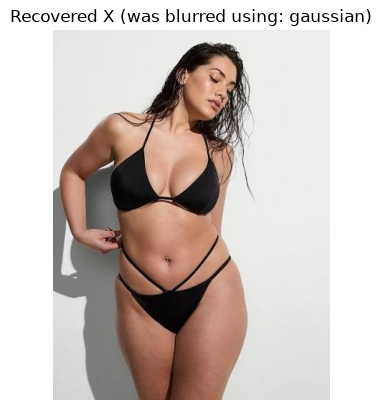

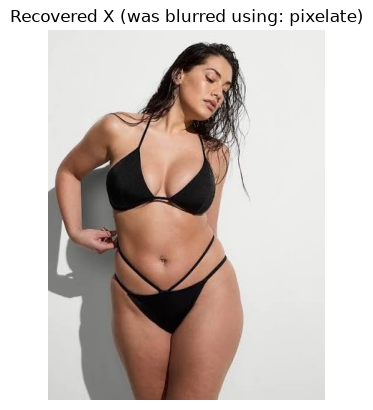

array([[[227, 229, 229],
        [227, 229, 229],
        [227, 229, 229],
        ...,
        [235, 237, 237],
        [235, 237, 237],
        [235, 237, 237]],

       [[227, 229, 229],
        [227, 229, 229],
        [227, 229, 229],
        ...,
        [235, 237, 237],
        [235, 237, 237],
        [235, 237, 237]],

       [[227, 229, 229],
        [227, 229, 229],
        [227, 229, 229],
        ...,
        [235, 237, 237],
        [235, 237, 237],
        [235, 237, 237]],

       ...,

       [[208, 210, 210],
        [208, 210, 210],
        [208, 210, 210],
        ...,
        [217, 219, 219],
        [217, 219, 219],
        [217, 219, 219]],

       [[208, 210, 210],
        [208, 210, 210],
        [208, 210, 210],
        ...,
        [217, 219, 219],
        [217, 219, 219],
        [217, 219, 219]],

       [[208, 210, 210],
        [208, 210, 210],
        [208, 210, 210],
        ...,
        [217, 219, 219],
        [217, 219, 219],
        [217, 219, 219]]

In [33]:
find_by_hash(gaussian_hash)
find_by_hash(pixelate_hash)